In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import random
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from datetime import datetime
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================
INPUT_FOLDER = "/home/user2/archive(9)/CIC_IOT_Dataset2023/MERGED_CSV"
OUTPUT_FOLDER = "/home/user2/archive(9)"
USE_SAMPLE_SIZE = 100000
DETECTION_EPOCHS = 100
RESPONSE_EPISODES = 8000
BATCH_SIZE = 256
LEARNING_RATE = 0.001
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print("\n" + "=" * 80)
print(" AMD AI CYBERSECURITY - POST-QUANTUM DEFENSE SYSTEM")
print("=" * 80)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("=" * 80)



 AMD AI CYBERSECURITY - POST-QUANTUM DEFENSE SYSTEM
Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [4]:
# ============================================================================
# THREAT EXPLANATION SYSTEM
# ============================================================================
def explain_threat(threat_class, confidence, threat_names, context=None):
    """
    Generate human-readable explanations for detected threats.
    Based on cybersecurity best practices and threat analysis frameworks.
    
    Args:
        threat_class (int): The detected threat class (0-11)
        confidence (float): Detection confidence (0-1)
        threat_names (list): List of threat class names
        context (dict): Optional context information (system health, crypto strength, etc.)
    
    Returns:
        dict: Structured explanation with threat details, risks, and recommendations
    """
    
    threat_name = threat_names[threat_class]
    confidence_pct = confidence * 100
    
    # Base explanations for each threat type
    explanations = {
        # Classical Threats (0-7)
        0: {  # Benign
            "severity": "LOW",
            "category": "Normal Traffic",
            "description": "This traffic appears to be legitimate normal network activity.",
            "technical_detail": "No malicious patterns detected in packet headers, payload, or behavioral characteristics.",
            "risk": "No immediate threat detected.",
            "recommendation": "Continue monitoring. No action required.",
            "indicators": ["Normal packet rate", "Standard protocol usage", "Expected communication patterns"]
        },
        
        1: {  # DDoS
            "severity": "CRITICAL",
            "category": "Distributed Denial of Service",
            "description": "A coordinated attack attempting to overwhelm system resources by flooding the network with traffic from multiple sources.",
            "technical_detail": "Abnormally high packet rates from distributed sources, characteristic of botnet activity. This matches DDoS attack signatures including SYN floods, UDP floods, or HTTP floods.",
            "risk": "Service disruption, network congestion, potential system crash. Can mask other attacks.",
            "recommendation": "Immediately activate DDoS mitigation: enable rate limiting, deploy traffic filtering, isolate affected services. Contact ISP for upstream filtering.",
            "indicators": ["High packet volume", "Multiple source IPs", "Repeated connection attempts", "Resource exhaustion patterns"]
        },
        
        2: {  # DoS
            "severity": "HIGH",
            "category": "Denial of Service",
            "description": "An attack attempting to make network resources unavailable by overwhelming the system from a single source.",
            "technical_detail": "Abnormal traffic volume or malformed packets designed to consume system resources. May exploit specific protocol weaknesses or implementation bugs.",
            "risk": "Service unavailability, system slowdown, potential crash. Can be used for reconnaissance.",
            "recommendation": "Block source IP immediately. Implement connection rate limiting. Monitor for follow-up attacks.",
            "indicators": ["Single source, high volume", "Malformed packets", "Protocol violations", "Resource consumption spike"]
        },
        
        3: {  # Recon
            "severity": "MEDIUM",
            "category": "Reconnaissance/Scanning",
            "description": "Systematic probing of network infrastructure to identify vulnerabilities, open ports, or system fingerprints.",
            "technical_detail": "Port scanning, OS fingerprinting, or service enumeration activity. Attacker is mapping your network topology and identifying potential entry points.",
            "risk": "Precursor to targeted attack. Information gathering phase that often precedes exploitation attempts.",
            "recommendation": "Log all activity for forensic analysis. Implement honeypot services. Reduce visible attack surface. Monitor for escalation to active exploitation.",
            "indicators": ["Sequential port scans", "OS fingerprinting attempts", "Service version queries", "Network mapping patterns"]
        },
        
        4: {  # Web-based
            "severity": "HIGH",
            "category": "Web Application Attack",
            "description": "Attack targeting web application vulnerabilities such as SQL injection, Cross-Site Scripting (XSS), or Remote Code Execution.",
            "technical_detail": "Malicious payloads in HTTP requests attempting to exploit web application weaknesses. May include SQL commands, script tags, or path traversal sequences.",
            "risk": "Data breach, database compromise, user session hijacking, server takeover.",
            "recommendation": "Block malicious requests. Update WAF rules. Patch vulnerable applications immediately. Audit database for unauthorized access.",
            "indicators": ["SQL injection patterns", "XSS payloads", "Directory traversal attempts", "Malformed HTTP requests"]
        },
        
        5: {  # BruteForce
            "severity": "HIGH",
            "category": "Credential Brute Force",
            "description": "Automated attack attempting to gain unauthorized access by systematically trying username/password combinations.",
            "technical_detail": "Repeated authentication attempts with different credentials, often using common password lists or leaked credential databases.",
            "risk": "Account compromise, unauthorized access, data theft, lateral movement within network.",
            "recommendation": "Implement account lockout policies. Enable multi-factor authentication. Deploy CAPTCHA. Monitor for successful authentications from attack source.",
            "indicators": ["Repeated login failures", "Dictionary attack patterns", "Rapid authentication attempts", "Multiple account targeting"]
        },
        
        6: {  # Spoofing
            "severity": "HIGH",
            "category": "Identity Spoofing",
            "description": "Attack where adversary falsifies data to impersonate a trusted entity, including IP spoofing, ARP spoofing, or DNS spoofing.",
            "technical_detail": "Forged packet headers or protocol messages designed to appear as legitimate traffic from trusted sources. Can enable Man-in-the-Middle attacks.",
            "risk": "Data interception, traffic redirection, session hijacking, unauthorized access.",
            "recommendation": "Enable egress/ingress filtering. Implement cryptographic authentication. Use ARP inspection and DNSSEC. Verify source authenticity.",
            "indicators": ["Mismatched MAC/IP bindings", "Duplicate IP addresses", "Suspicious ARP replies", "DNS response anomalies"]
        },
        
        7: {  # Mirai/IoT Botnet
            "severity": "CRITICAL",
            "category": "IoT Botnet Activity",
            "description": "Compromised IoT device exhibiting botnet command-and-control communication or participating in coordinated attacks.",
            "technical_detail": "Traffic patterns consistent with Mirai or similar IoT malware: C2 beaconing, lateral propagation attempts, or participation in DDoS campaigns.",
            "risk": "Device compromise, participation in large-scale attacks, data exfiltration, network propagation.",
            "recommendation": "Isolate infected device immediately. Reset to factory defaults. Update firmware. Change default credentials. Implement network segmentation for IoT devices.",
            "indicators": ["C2 communication patterns", "Telnet/SSH brute force", "Known Mirai signatures", "Unusual outbound connections"]
        },
        
        # Post-Quantum Threats (8-11)
        8: {  # PQ-Downgrade
            "severity": "CRITICAL",
            "category": "Post-Quantum Cryptographic Downgrade",
            "description": "Attack attempting to force use of cryptographic algorithms vulnerable to quantum computers by degrading cipher suite negotiation.",
            "technical_detail": "Manipulation of TLS handshake or cryptographic protocol negotiation to prevent use of post-quantum safe algorithms. Attacker forces fallback to RSA, ECDH, or other quantum-vulnerable primitives.",
            "risk": "Future decryption by quantum computers. 'Harvest Now, Decrypt Later' vulnerability. Long-term confidentiality compromise.",
            "recommendation": "URGENT: Enforce post-quantum cipher suites only. Disable fallback to classical algorithms. Deploy quantum-safe TLS configurations. Audit all cryptographic protocols.",
            "indicators": ["Forced cipher suite negotiation", "Repeated handshake failures", "Version rollback attempts", "Crypto algorithm downgrade"]
        },
        
        9: {  # PQ-HNDL (Harvest Now, Decrypt Later)
            "severity": "CRITICAL",
            "category": "Harvest Now, Decrypt Later Attack",
            "description": "Adversary capturing encrypted data for future decryption when quantum computers become available. Data with long-term confidentiality requirements is at risk.",
            "technical_detail": "Large-scale traffic collection focusing on encrypted communications. Attacker stores encrypted data now, planning to decrypt it when quantum computers can break current encryption (estimated 5-15 years).",
            "risk": "Future exposure of sensitive data including: medical records, financial data, intellectual property, state secrets, personal communications.",
            "recommendation": "IMMEDIATE ACTION: Migrate to post-quantum encryption for all sensitive data. Implement quantum-safe key exchange. Re-encrypt archived sensitive data with PQ algorithms.",
            "indicators": ["Unusual traffic capture", "Bulk encrypted data collection", "Passive monitoring signatures", "Long-term data retention patterns"]
        },
        
        10: {  # PQ-SideChannel
            "severity": "HIGH",
            "category": "Post-Quantum Side-Channel Attack",
            "description": "Exploitation of implementation weaknesses in post-quantum cryptographic algorithms through timing analysis, power consumption, or electromagnetic emissions.",
            "technical_detail": "Attack targeting physical implementation of PQ algorithms (lattice-based, hash-based, code-based). Exploits correlation between secret key operations and observable physical phenomena.",
            "risk": "Private key recovery from PQ cryptosystems. Compromise of quantum-safe encryption despite using correct algorithms.",
            "recommendation": "Update PQ crypto implementations to side-channel resistant versions. Implement constant-time operations. Add masking and blinding countermeasures. Monitor for timing anomalies.",
            "indicators": ["Timing analysis patterns", "Repeated PQ operations", "Statistical correlation attacks", "Cache timing exploits"]
        },
        
        11: {  # PQ-Hybrid
            "severity": "CRITICAL",
            "category": "Hybrid Classical-Quantum Attack",
            "description": "Sophisticated attack combining classical cryptanalysis with quantum-enabled techniques, or exploiting transition vulnerabilities during migration to PQ cryptography.",
            "technical_detail": "Multi-vector attack exploiting both classical and quantum vulnerabilities. May target hybrid classical-PQ cryptosystems, implementation bugs in PQ libraries, or protocol weaknesses during crypto agility transitions.",
            "risk": "Complete cryptographic failure. Bypasses both classical and quantum-safe protections. Particularly dangerous during migration period.",
            "recommendation": "CRITICAL: Full security audit of PQ implementation. Verify proper hybrid mode operation. Test crypto agility mechanisms. Implement defense-in-depth with multiple PQ algorithms.",
            "indicators": ["Combined attack signatures", "PQ implementation probing", "Hybrid protocol exploitation", "Crypto transition attacks"]
        }
    }
    
    # Get base explanation
    explanation = explanations.get(threat_class, {
        "severity": "UNKNOWN",
        "category": "Unknown Threat",
        "description": "Unrecognized threat pattern detected.",
        "technical_detail": "Traffic does not match known threat signatures.",
        "risk": "Unknown risk level. Requires investigation.",
        "recommendation": "Isolate and analyze. Contact security team.",
        "indicators": ["Anomalous behavior"]
    })
    
    # Add confidence-based context
    if confidence_pct > 95:
        confidence_note = "High confidence detection - signature match is very strong."
    elif confidence_pct > 80:
        confidence_note = "Good confidence - multiple indicators align with this threat type."
    elif confidence_pct > 60:
        confidence_note = "Moderate confidence - some indicators match, manual verification recommended."
    else:
        confidence_note = "Low confidence - possible false positive, requires expert analysis."
    
    # Add system context if provided
    context_notes = []
    if context:
        if context.get('system_health', 100) < 50:
            context_notes.append("⚠️ System health degraded - attack may be having impact.")
        if context.get('crypto_strength', 100) < 70 and threat_class >= 8:
            context_notes.append("🔐 Cryptographic strength weakened - PQ threat is actively degrading security.")
        if context.get('repeated_attacks', 0) > 3:
            context_notes.append("🔄 Multiple attack attempts detected - persistent adversary.")
    
    # Build complete explanation
    result = {
        "threat_name": threat_name,
        "threat_class": threat_class,
        "severity": explanation["severity"],
        "category": explanation["category"],
        "confidence": confidence_pct,
        "confidence_note": confidence_note,
        "description": explanation["description"],
        "technical_detail": explanation["technical_detail"],
        "risk": explanation["risk"],
        "recommendation": explanation["recommendation"],
        "indicators": explanation["indicators"],
        "is_post_quantum": threat_class >= 8,
        "context_notes": context_notes,
        "timestamp": datetime.now().isoformat()
    }
    
    return result


In [5]:
def format_threat_explanation(explanation):
    """
    Format threat explanation for user display.
    
    Args:
        explanation (dict): Structured explanation from explain_threat()
    
    Returns:
        str: Formatted, human-readable explanation
    """
    
    severity_emoji = {
        "LOW": "🟢",
        "MEDIUM": "🟡",
        "HIGH": "🟠",
        "CRITICAL": "🔴",
        "UNKNOWN": "⚪"
    }
    
    output = []
    output.append("\n" + "=" * 80)
    output.append(f"{severity_emoji.get(explanation['severity'], '⚪')} THREAT DETECTED: {explanation['threat_name']}")
    output.append("=" * 80)
    
    output.append(f"\n📊 DETECTION DETAILS:")
    output.append(f"   Severity:    {explanation['severity']}")
    output.append(f"   Category:    {explanation['category']}")
    output.append(f"   Confidence:  {explanation['confidence']:.1f}%")
    output.append(f"   Note:        {explanation['confidence_note']}")
    
    if explanation['is_post_quantum']:
        output.append(f"   Type:        🔐 POST-QUANTUM THREAT")
    
    output.append(f"\n❓ WHAT IS THIS?")
    output.append(f"   {explanation['description']}")
    
    output.append(f"\n🔬 TECHNICAL ANALYSIS:")
    output.append(f"   {explanation['technical_detail']}")
    
    output.append(f"\n⚠️ RISK:")
    output.append(f"   {explanation['risk']}")
    
    output.append(f"\n✅ RECOMMENDED ACTION:")
    output.append(f"   {explanation['recommendation']}")
    
    output.append(f"\n🔍 ATTACK INDICATORS:")
    for indicator in explanation['indicators']:
        output.append(f"   • {indicator}")
    
    if explanation['context_notes']:
        output.append(f"\n📌 ADDITIONAL CONTEXT:")
        for note in explanation['context_notes']:
            output.append(f"   {note}")
    
    output.append("\n" + "=" * 80)
    
    return "\n".join(output)

In [6]:
# ============================================================================
# DATA LOADER
# ============================================================================
class ImprovedDataLoader:
    def __init__(self, data_path=INPUT_FOLDER, sample_size=USE_SAMPLE_SIZE):
        self.data_path = Path(data_path) if data_path else None
        self.sample_size = sample_size
        self.scaler = StandardScaler()
        
        self.classical_threats = {
            'Benign': 0, 'DDoS': 1, 'DoS': 2, 'Recon': 3,
            'Web_based': 4, 'BruteForce': 5, 'Spoofing': 6, 'Mirai': 7
        }
        
        self.pq_threats = {
            'PQ-Downgrade': 8, 'PQ-HNDL': 9, 'PQ-SideChannel': 10, 'PQ-Hybrid': 11
        }
        
        self.all_threats = {**self.classical_threats, **self.pq_threats}
        self.threat_names = list(self.all_threats.keys())
        self.num_classical = len(self.classical_threats)
        self.num_pq = len(self.pq_threats)
        self.num_total = len(self.all_threats)
        
        print("\n📊 DATASET CONFIGURATION")
        print(f"Classical Threats: {self.num_classical}")
        print(f"PQ Threats: {self.num_pq}")
        print(f"Total Classes: {self.num_total}")
    
    def load_dataset(self):
        X_classical, y_classical, num_features = self._load_classical_threats()
        
        # Generate PQ samples with distinct patterns
        pq_samples = int(len(X_classical) * 0.4)
        X_pq, y_pq = self._generate_distinct_pq_threats(
            X_classical, y_classical, num_features, pq_samples
        )
        
        X_combined = np.vstack([X_classical, X_pq])
        y_combined = np.concatenate([y_classical, y_pq])
        
        # Balance classes
        X_combined, y_combined = self._balance_classes(X_combined, y_combined)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_combined, y_combined, test_size=0.2, random_state=SEED, stratify=y_combined
        )
        
        print(f"\n✅ Dataset: {len(X_train):,} train, {len(X_test):,} test")
        print(f"   Features: {num_features}")
        np.save(str("/home/user2/archive(9)/X_train.npy"), X_train)
        np.save(str("/home/user2/archive(9)/X_test.npy"),  X_test)
        np.save(str("/home/user2/archive(9)/y_train.npy"), y_train)
        np.save(str("/home/user2/archive(9)/y_test.npy"),  y_test)
        print("💾 Train/test splits saved")
        return X_train, X_test, y_train, y_test, num_features
    
    def _balance_classes(self, X, y):
        """Equal samples per class for balanced learning"""
        print("\n⚖️  Balancing classes equally...")
        unique_labels, counts = np.unique(y, return_counts=True)
        target_count = int(np.mean(counts))
        
        X_balanced = []
        y_balanced = []
        
        for label in unique_labels:
            mask = y == label
            X_class = X[mask]
            y_class = y[mask]
            current_count = len(X_class)
            
            if current_count < target_count:
                indices = np.random.choice(current_count, target_count, replace=True)
                X_class = X_class[indices]
                y_class = y_class[indices]
            elif current_count > target_count:
                indices = np.random.choice(current_count, target_count, replace=False)
                X_class = X_class[indices]
                y_class = y_class[indices]
            
            X_balanced.append(X_class)
            y_balanced.append(y_class)
            print(f"   Class {label} ({self.threat_names[label]}): {len(X_class):,} samples")
        
        X_balanced = np.vstack(X_balanced)
        y_balanced = np.concatenate(y_balanced)
        
        shuffle_idx = np.random.permutation(len(X_balanced))
        return X_balanced[shuffle_idx], y_balanced[shuffle_idx]
    
    def _generate_distinct_pq_threats(self, X_classical, y_classical, num_features, num_samples):
        """Generate PQ threats with clear, distinct patterns"""
        print("\n🔐 GENERATING DISTINCT PQ THREATS")
        
        X_pq = []
        y_pq = []
        samples_per_class = num_samples // self.num_pq
        
        for pq_class in range(self.num_pq):
            pq_class_id = self.num_classical + pq_class
            
            for _ in range(samples_per_class):
                idx = np.random.randint(0, len(X_classical))
                sample = X_classical[idx].copy()
                
                if pq_class == 0:  # PQ-Downgrade
                    crypto_idx = np.random.choice(num_features, num_features // 4, replace=False)
                    sample[crypto_idx] *= np.random.uniform(0.3, 0.6)
                    spike_idx = np.random.choice(num_features, num_features // 10, replace=False)
                    sample[spike_idx] += np.random.uniform(1.5, 2.5)
                    
                elif pq_class == 1:  # PQ-HNDL
                    timing_idx = np.random.choice(num_features, num_features // 3, replace=False)
                    sample[timing_idx] *= np.random.uniform(1.8, 2.5)
                    osc_idx = np.random.choice(num_features, num_features // 8, replace=False)
                    sample[osc_idx] *= np.sin(np.linspace(0, 4*np.pi, len(osc_idx))) + 1.5
                    
                elif pq_class == 2:  # PQ-SideChannel
                    side_idx = np.random.choice(num_features, num_features // 3, replace=False)
                    sample[side_idx] *= np.random.choice([0.4, 2.0], len(side_idx))
                    noise_idx = np.random.choice(num_features, num_features // 6, replace=False)
                    sample[noise_idx] += np.random.uniform(-1.0, 1.0, len(noise_idx))
                    
                elif pq_class == 3:  # PQ-Hybrid
                    hybrid1 = np.random.choice(num_features, num_features // 4, replace=False)
                    hybrid2 = np.random.choice(num_features, num_features // 4, replace=False)
                    sample[hybrid1] *= np.random.uniform(0.4, 0.7)
                    sample[hybrid2] *= np.random.uniform(1.6, 2.2)
                    corr_idx = np.random.choice(num_features, num_features // 6, replace=False)
                    sample[corr_idx] = sample[corr_idx].mean() + np.random.uniform(-0.5, 0.5)
                
                sample += np.random.normal(0, 0.05, num_features)
                sample = np.clip(sample, -3, 4)
                
                X_pq.append(sample)
                y_pq.append(pq_class_id)
        
        print(f"    Generated {len(X_pq):,} PQ samples with distinct patterns")
        return np.array(X_pq), np.array(y_pq)
    
    def _load_classical_threats(self):
        print("\n📁 LOADING CLASSICAL THREATS")
        
        if not self.data_path or not self.data_path.exists():
            return self._generate_synthetic_classical_data()
        
        csv_files = sorted(list(self.data_path.glob("**/*.csv")))
        if not csv_files:
            return self._generate_synthetic_classical_data()
        
        files_to_load = csv_files[:5]
        dfs = []
        for csv_file in files_to_load:
            try:
                df = pd.read_csv(csv_file, low_memory=False, encoding='utf-8')
                dfs.append(df)
                print(f"   ✓ {csv_file.name}")
            except:
                pass
        
        if not dfs:
            return self._generate_synthetic_classical_data()
        
        df = pd.concat(dfs, ignore_index=True)
        
        if self.sample_size and len(df) > self.sample_size:
            df = df.sample(n=self.sample_size, random_state=SEED)
        
        label_col = self._find_label_column(df)
        if label_col is None:
            return self._generate_synthetic_classical_data()
        
        X, y, num_features = self._preprocess_data(df, label_col)
        return X, y, num_features
    
    def _find_label_column(self, df):
        for name in ['label', 'Label', ' label', 'attack', 'Attack']:
            if name in df.columns:
                return name
        for col in df.columns:
            if 'label' in col.lower():
                return col
        return None
    
    def _preprocess_data(self, df, label_col):
        y_raw = df[label_col]
        X = df.drop(columns=[label_col])
        
        y_mapped = self._map_labels_to_categories(y_raw)
        
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        X = X[numeric_cols]
        X = X.replace([np.inf, -np.inf], np.nan)
        X = X.fillna(X.median(numeric_only=True))
        
        variance = X.var(numeric_only=True)
        X = X.loc[:, variance > 0]
        
        X_scaled = self.scaler.fit_transform(X)
        return X_scaled, y_mapped, X_scaled.shape[1]
    
    def _map_labels_to_categories(self, y_raw):
        y_mapped = np.zeros(len(y_raw), dtype=int)
        for i, label in enumerate(y_raw):
            label_lower = str(label).lower()
            if 'benign' in label_lower:
                y_mapped[i] = 0
            elif 'ddos' in label_lower:
                y_mapped[i] = 1
            elif 'dos' in label_lower:
                y_mapped[i] = 2
            elif 'recon' in label_lower or 'scan' in label_lower:
                y_mapped[i] = 3
            elif 'web' in label_lower or 'sql' in label_lower:
                y_mapped[i] = 4
            elif 'brute' in label_lower:
                y_mapped[i] = 5
            elif 'spoof' in label_lower:
                y_mapped[i] = 6
            elif 'mirai' in label_lower or 'bot' in label_lower:
                y_mapped[i] = 7
            else:
                y_mapped[i] = 0
        return y_mapped
    
    def _generate_synthetic_classical_data(self):
        print("⚡ Generating synthetic classical data...")
        num_features = 47
        num_samples = self.sample_size if self.sample_size else 100000
        
        X = []
        y = []
        samples_per_class = num_samples // self.num_classical
        
        for class_id in range(self.num_classical):
            for _ in range(samples_per_class):
                if class_id == 0:  # Benign
                    sample = np.random.normal(0.2, 0.15, num_features)
                elif class_id == 1:  # DDoS
                    sample = np.random.normal(0.8, 0.2, num_features)
                    sample[0:12] *= np.random.uniform(2.5, 3.5)
                elif class_id == 2:  # DoS
                    sample = np.random.normal(0.75, 0.18, num_features)
                    sample[5:17] *= np.random.uniform(2.2, 3.0)
                elif class_id == 3:  # Recon
                    sample = np.random.normal(0.45, 0.2, num_features)
                    sample[15:27] *= np.random.uniform(1.7, 2.5)
                elif class_id == 4:  # Web-based
                    sample = np.random.normal(0.65, 0.18, num_features)
                    sample[20:32] *= np.random.uniform(2.0, 2.8)
                elif class_id == 5:  # BruteForce
                    sample = np.random.normal(0.78, 0.17, num_features)
                    sample[25:37] *= np.random.uniform(2.3, 3.1)
                elif class_id == 6:  # Spoofing
                    sample = np.random.normal(0.55, 0.22, num_features)
                    sample[30:42] *= np.random.uniform(1.8, 2.6)
                elif class_id == 7:  # Mirai
                    sample = np.random.normal(0.88, 0.15, num_features)
                    sample[35:47] *= np.random.uniform(2.6, 3.4)
                else:
                    sample = np.random.normal(0.5, 0.2, num_features)
                
                sample += np.random.normal(0, 0.06, num_features)
                sample = np.clip(sample, -0.5, 2.0)
                X.append(sample)
                y.append(class_id)
        
        X = np.array(X)
        y = np.array(y)
        X = self.scaler.fit_transform(X)
        
        return X, y, num_features

In [7]:
 #============================================================================
# THREAT DETECTOR MODEL
# ============================================================================
class EffectiveThreatDetector(nn.Module):
    """
    ResNet-style architecture for threat detection.
    Handles 12 threat classes including 4 post-quantum threats.
    """
    def __init__(self, input_dim=47, num_classes=12):
        super().__init__()
        
        # Input normalization
        self.input_bn = nn.BatchNorm1d(input_dim)
        
        # Feature extraction with residual connections
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        
        # Residual shortcut
        self.shortcut = nn.Linear(input_dim, 256)
        
        # Deeper feature learning
        self.deep_features = nn.Sequential(
            nn.Linear(256, 192),
            nn.BatchNorm1d(192),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(192, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_classes)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Normalize input
        x = self.input_bn(x)
        
        # Residual connection
        identity = self.shortcut(x)
        out = self.encoder(x)
        out = out + identity
        out = F.relu(out)
        
        # Deep features
        out = self.deep_features(out)
        
        # Classify
        logits = self.classifier(out)
        return logits
    
    def get_probabilities(self, x):
        return F.softmax(self.forward(x), dim=1)

In [8]:
# ============================================================================
# LOSS FUNCTION
# ============================================================================
class WeightedFocalLoss(nn.Module):
    """Focal loss with class weights for handling imbalanced data"""
    def __init__(self, alpha=None, gamma=2.0, num_classes=12):
        super().__init__()
        if alpha is None:
            alpha = torch.ones(num_classes)
        self.register_buffer('alpha', alpha / alpha.sum())
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha[targets] * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


# ============================================================================
# TRAINING FUNCTION
# ============================================================================
def train_detector(model, X_train, y_train, X_test, y_test,
                   num_epochs=DETECTION_EPOCHS, batch_size=BATCH_SIZE):
    print("\n🔧 TRAINING DETECTOR")
    print(f"Epochs: {num_epochs}, Batch Size: {batch_size}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Split validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
    )
    
    X_train_tensor = torch.FloatTensor(X_tr)
    y_train_tensor = torch.LongTensor(y_tr)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.LongTensor(y_val).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)
    
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    
    criterion = WeightedFocalLoss(gamma=2.0, num_classes=12).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10
    )
    
    train_losses, train_accuracies, test_accuracies = [], [], []
    test_losses=[]
    best_val_acc = 0
    best_model_state = None
    patience = 35
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            epoch_correct += (predicted == y_batch).sum().item()
            epoch_total += y_batch.size(0)
        
        avg_loss = epoch_loss / len(train_loader)
        train_acc = 100 * epoch_correct / epoch_total
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_pred = val_logits.argmax(dim=1)
            val_acc = 100 * (val_pred == y_val_tensor).float().mean().item()
            
            test_logits = model(X_test_tensor)
            test_pred = test_logits.argmax(dim=1)
            test_acc = 100 * (test_pred == y_test_tensor).float().mean().item()
        with torch.no_grad():
            
            test_loss = criterion(model(X_test_tensor), y_test_tensor).item()
        test_losses.append(test_loss)
        train_losses.append(avg_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Loss: {avg_loss:.4f} | "
                  f"Train: {train_acc:.2f}% | "
                  f"Val: {val_acc:.2f}% | "
                  f"Test: {test_acc:.2f}%")
        
        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Restored best model (Val Acc: {best_val_acc:.2f}%)")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return train_losses, test_losses, train_accuracies, test_accuracies


In [9]:
# ============================================================================
# RESPONSE AGENT DQN
# ============================================================================
class ImprovedResponseDQN(nn.Module):
    """Deep Q-Network for response action selection"""
    def __init__(self, state_dim=15, action_dim=8):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),
            
            nn.Linear(64, action_dim)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)

In [10]:
class BetterResponseEnvironment:
    """Environment for training response agent"""
    def __init__(self, detector_model, threat_names, X_test, y_test):
        self.detector = detector_model
        self.threat_names = threat_names
        self.X_test = torch.FloatTensor(X_test).to(device)
        self.y_test = y_test
        
        self.actions = {
            0: "Ignore", 1: "Quick Scan", 2: "Full Scan", 3: "Quarantine",
            4: "Delete", 5: "Network Isolate", 6: "PQ-Crypto Upgrade", 7: "Emergency Crypto Rotate"
        }
        
        self.optimal_actions = {
            0: 0, 1: 5, 2: 2, 3: 1, 4: 4, 5: 3, 6: 2, 7: 5,
            8: 6, 9: 7, 10: 6, 11: 7
        }
        
        self.correct_action_reward = {
            0: 10, 1: 40, 2: 30, 3: 25, 4: 35, 5: 35, 6: 30, 7: 45,
            8: 60, 9: 70, 10: 60, 11: 70
        }
        
        self.reset()
    
    def reset(self):
        self.current_idx = np.random.randint(0, len(self.X_test))
        sample = self.X_test[self.current_idx:self.current_idx+1]
        self.true_label = int(self.y_test[self.current_idx])
        
        with torch.no_grad():
            threat_probs = self.detector.get_probabilities(sample)
            self.detected_threat = int(torch.argmax(threat_probs).item())
            self.confidence = float(threat_probs[0, self.detected_threat].item())
        
        self.system_health = np.random.uniform(0.7, 1.0)
        self.crypto_strength = np.random.uniform(0.7, 1.0)
        
        return self._get_state()
    
    def _get_state(self):
        is_pq_true = 1.0 if self.true_label >= 8 else 0.0
        is_pq_detected = 1.0 if self.detected_threat >= 8 else 0.0
        detection_correct = 1.0 if self.true_label == self.detected_threat else 0.0
        
        state = np.array([
            self.detected_threat / 11.0,
            self.confidence,
            detection_correct,
            is_pq_detected,
            is_pq_true,
            self.system_health,
            self.crypto_strength,
            (1.0 - self.confidence) * 0.5 + (1.0 - detection_correct) * 0.5,
            is_pq_true * (1.0 - self.crypto_strength),
            (1.0 - self.system_health) * 0.5,
            1.0 if self.detected_threat < 4 else 0.0,
            1.0 if 4 <= self.detected_threat < 8 else 0.0,
            1.0 if self.detected_threat >= 8 else 0.0,
            1.0 if self.confidence > 0.9 and self.detected_threat > 0 else 0.0,
            1.0 if is_pq_detected and self.crypto_strength < 0.8 else 0.0,
        ], dtype=np.float32)
        
        return torch.FloatTensor(state).unsqueeze(0).to(device)
    
    def step(self, action):
        optimal_action = self.optimal_actions[self.true_label]
        is_pq = self.true_label >= 8
        
        if action == optimal_action:
            reward = self.correct_action_reward[self.true_label]
            if self.confidence > 0.9:
                reward += 15
            if is_pq:
                reward += 20
        else:
            if self.true_label == 0:
                if action in [3, 4, 5]:
                    reward = -40
                else:
                    reward = -20
            elif self.true_label != 0 and action == 0:
                reward = -80 if is_pq else -50
            else:
                reward = -40 if is_pq else -25
        
        if action == optimal_action:
            self.system_health = min(1.0, self.system_health + 0.15)
            if action in [6, 7]:
                self.crypto_strength = min(1.0, self.crypto_strength + 0.20)
        else:
            self.system_health = max(0.0, self.system_health - 0.25)
            if is_pq:
                self.crypto_strength = max(0.0, self.crypto_strength - 0.20)
        
        info = {
            'true_threat': self.threat_names[self.true_label],
            'detected_threat': self.threat_names[self.detected_threat],
            'confidence': self.confidence,
            'optimal_action': self.actions[optimal_action],
            'taken_action': self.actions[action],
            'correct': action == optimal_action,
            'is_pq': bool(is_pq),
            'crypto_strength': self.crypto_strength
        }
        
        return self._get_state(), reward, True, info


class PrioritizedReplayBuffer:
    def __init__(self, capacity=30000):
        self.buffer = deque(maxlen=capacity)
        self.priorities = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        self.priorities.append(abs(reward) + 1.0)
    
    def sample(self, batch_size):
        probs = np.array(self.priorities) / sum(self.priorities)
        indices = np.random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            torch.cat(states),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.cat(next_states),
            torch.FloatTensor(dones).to(device)
        )
    
    def __len__(self):
        return len(self.buffer)

In [11]:
def train_improved_response_agent(detector_model, threat_names, X_test, y_test,
                                   num_episodes=RESPONSE_EPISODES, batch_size=256):
    print("\n🤖 TRAINING RESPONSE AGENT")
    print(f"Episodes: {num_episodes}")
    
    env = BetterResponseEnvironment(detector_model, threat_names, X_test, y_test)
    
    policy_net = ImprovedResponseDQN(state_dim=15, action_dim=8).to(device)
    target_net = ImprovedResponseDQN(state_dim=15, action_dim=8).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    
    optimizer = optim.AdamW(policy_net.parameters(), lr=0.0003, weight_decay=1e-5)
    replay_buffer = PrioritizedReplayBuffer(capacity=30000)
    
    epsilon = 1.0
    epsilon_decay = 0.9992
    epsilon_min = 0.02
    gamma = 0.99
    target_update = 5
    
    episode_rewards = []
    accuracies = []
    pq_correct = 0
    pq_total = 0
    
    for episode in range(num_episodes):
        state = env.reset()
        
        if random.random() < epsilon:
            action = random.randint(0, 7)
        else:
            with torch.no_grad():
                q_values = policy_net(state)
                action = int(q_values.argmax().item())
        
        next_state, reward, done, info = env.step(action)
        replay_buffer.push(state, action, reward, next_state, done)
        
        if info['is_pq']:
            pq_total += 1
            if info['correct']:
                pq_correct += 1
        
        if len(replay_buffer) > batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
            
            q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
            
            with torch.no_grad():
                next_actions = policy_net(next_states).argmax(dim=1)
                next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                target_q_values = rewards + gamma * next_q_values * (1 - dones)
            
            loss = F.smooth_l1_loss(q_values, target_q_values)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
            optimizer.step()
        
        episode_rewards.append(reward)
        accuracies.append(1.0 if info['correct'] else 0.0)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if (episode + 1) % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())
        
        if (episode + 1) % 500 == 0:
            avg_reward = np.mean(episode_rewards[-500:])
            avg_accuracy = np.mean(accuracies[-500:]) * 100
            pq_acc = (pq_correct / pq_total * 100) if pq_total > 0 else 0
            print(f"Episode [{episode+1}/{num_episodes}] "
                  f"Reward: {avg_reward:.2f} | Acc: {avg_accuracy:.1f}% | PQ: {pq_acc:.1f}% | ε: {epsilon:.3f}")
            pq_correct = 0
            pq_total = 0
    
    print(f"\n✅ Response Training Complete!")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return policy_net, episode_rewards, accuracies

In [12]:
# ============================================================================
# EVALUATION
# ============================================================================
def evaluate_system(detector, response_agent, threat_names, X_test, y_test, num_tests=2000):
    print("\n📊 EVALUATING SYSTEM")
    
    env = BetterResponseEnvironment(detector, threat_names, X_test, y_test)
    
    y_true_detection = []
    y_pred_detection = []
    y_true_response = []
    y_pred_response = []
    total_reward = 0
    detection_confidences = []
    
    pq_detections_true = []
    pq_detections_pred = []
    pq_responses_correct = 0
    pq_responses_total = 0
    
    for _ in range(num_tests):
        state = env.reset()
        is_pq = env.true_label >= 8
        
        y_true_detection.append(env.true_label)
        y_pred_detection.append(env.detected_threat)
        detection_confidences.append(env.confidence)
        
        if is_pq:
            pq_detections_true.append(env.true_label)
            pq_detections_pred.append(env.detected_threat)
        
        with torch.no_grad():
            action = int(response_agent(state).argmax().item())
        
        optimal_action = env.optimal_actions[env.true_label]
        y_true_response.append(optimal_action)
        y_pred_response.append(action)
        
        _, reward, _, info = env.step(action)
        total_reward += reward
        
        if is_pq:
            pq_responses_total += 1
            if info['correct']:
                pq_responses_correct += 1
    
    detection_accuracy = accuracy_score(y_true_detection, y_pred_detection) * 100
    response_accuracy = accuracy_score(y_true_response, y_pred_response) * 100
    avg_confidence = np.mean(detection_confidences) * 100
    avg_reward = total_reward / num_tests
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_detection, y_pred_detection, average='weighted', zero_division=0
    )
    
    pq_detection_acc = accuracy_score(pq_detections_true, pq_detections_pred) * 100 if pq_detections_true else 0
    pq_response_acc = (pq_responses_correct / pq_responses_total * 100) if pq_responses_total > 0 else 0
    
    print(f"\n📈 RESULTS:")
    print(f"    Detection: {detection_accuracy:.2f}%")
    print(f"    PQ Detection: {pq_detection_acc:.2f}%")
    print(f"    Response: {response_accuracy:.2f}%")
    print(f"    PQ Response: {pq_response_acc:.2f}%")
    print(f"    F1-Score: {f1:.3f}")
    print(f"    Confidence: {avg_confidence:.1f}%")
    
    return {
        'detection_accuracy': detection_accuracy,
        'response_accuracy': response_accuracy,
        'precision': precision, 'recall': recall, 'f1_score': f1,
        'avg_confidence': avg_confidence, 'avg_reward': avg_reward,
        'pq_detection_accuracy': pq_detection_acc,
        'pq_response_accuracy': pq_response_acc,
        'y_true_detection': y_true_detection,
        'y_pred_detection': y_pred_detection
    }


In [13]:
# ============================================================================
# VISUALIZATION
# ============================================================================
def create_visualizations(results, train_losses, test_losses,train_accs, test_accs,
                         episode_rewards, response_accs, threat_names):
    print("\n📊 CREATING VISUALIZATIONS")
    
    fig = plt.figure(figsize=(20, 12))
    
    # Detection training
    ax1 = plt.subplot(3, 3, 1)
    ax1_twin = ax1.twinx()
    ax1.plot(train_losses, color='#2196F3', linestyle='-',  label='Train Loss', alpha=0.8, linewidth=2)
    ax1.plot(test_losses,  color='#FF5722', linestyle='-', label='Test Loss',  alpha=0.8, linewidth=2)
    ax1_twin.plot(train_accs, 'r-', label='Train Acc', alpha=0.7, linewidth=2)
    ax1_twin.plot(test_accs, 'g-', label='Test Acc', alpha=0.7, linewidth=2)
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Loss', fontweight='bold')
    ax1_twin.set_ylabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('Detection Training', fontweight='bold', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    
    # Response rewards
    ax2 = plt.subplot(3, 3, 2)
    window = 100
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    ax2.plot(smoothed, 'g-', linewidth=2)
    ax2.fill_between(range(len(smoothed)), smoothed, alpha=0.3, color='green')
    ax2.set_xlabel('Episode', fontweight='bold')
    ax2.set_ylabel('Avg Reward', fontweight='bold')
    ax2.set_title('Response Agent Learning', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=2)
    
    # Response accuracy
    ax3 = plt.subplot(3, 3, 3)
    smoothed_acc = np.convolve(response_accs, np.ones(window)/window, mode='valid') * 100
    ax3.plot(smoothed_acc, 'purple', linewidth=2)
    ax3.fill_between(range(len(smoothed_acc)), smoothed_acc, alpha=0.3, color='purple')
    ax3.set_xlabel('Episode', fontweight='bold')
    ax3.set_ylabel('Accuracy (%)', fontweight='bold')
    ax3.set_title('Response Accuracy', fontweight='bold', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 100])
    
    # Confusion matrix
    ax4 = plt.subplot(3, 3, 4)
    cm = confusion_matrix(results['y_true_detection'], results['y_pred_detection'])
    cm_normalized = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1) * 100
    cm_normalized = np.nan_to_num(cm_normalized, nan=0.0)
    
    short_names = [name if name.startswith('PQ-') else name[:6] for name in threat_names]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4,
                cbar_kws={'label': 'Accuracy (%)'}, xticklabels=short_names,
                yticklabels=short_names, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=100, square=True, annot_kws={'size': 7})
    
    ax4.set_xlabel('Predicted', fontweight='bold')
    ax4.set_ylabel('True', fontweight='bold')
    ax4.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax4.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
    
    # Performance metrics
    ax5 = plt.subplot(3, 3, 5)
    metrics = {
        'Detection': results['detection_accuracy'],
        'Response': results['response_accuracy'],
        'PQ Detect': results['pq_detection_accuracy'],
        'PQ Response': results['pq_response_accuracy'],
        'F1×100': results['f1_score'] * 100
    }
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
    bars = ax5.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='black', linewidth=1.5)
    ax5.set_ylabel('Score (%)', fontweight='bold')
    ax5.set_title('Performance Metrics', fontweight='bold', fontsize=12)
    ax5.set_ylim([0, 105])
    ax5.grid(True, axis='y', alpha=0.3)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Threat distribution
    ax6 = plt.subplot(3, 3, 6)
    unique, counts = np.unique(results['y_true_detection'], return_counts=True)
    colors_threats = ['#2E7D32' if i < 8 else '#C62828' for i in unique]
    ax6.bar([short_names[i] for i in unique], counts, color=colors_threats, 
           alpha=0.7, edgecolor='black', linewidth=1)
    ax6.set_ylabel('Count', fontweight='bold')
    ax6.set_title('Threat Distribution', fontweight='bold', fontsize=12)
    ax6.grid(True, axis='y', alpha=0.3)
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    
    # Key metrics boxes
    ax7 = plt.subplot(3, 3, 7)
    ax7.text(0.5, 0.8, f"Overall Accuracy\n{results['detection_accuracy']:.2f}%", 
             ha='center', va='center', fontsize=24, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='navy', linewidth=2))
    ax7.text(0.5, 0.4, f"F1-Score: {results['f1_score']:.3f}", 
             ha='center', va='center', fontsize=16, fontweight='bold')
    ax7.text(0.5, 0.2, f"Confidence: {results['avg_confidence']:.1f}%", 
             ha='center', va='center', fontsize=14, style='italic')
    ax7.axis('off')
    ax7.set_title('Key Metrics', fontweight='bold', fontsize=12)
    
    ax8 = plt.subplot(3, 3, 8)
    ax8.text(0.5, 0.8, f"PQ Detection\n{results['pq_detection_accuracy']:.2f}%", 
             ha='center', va='center', fontsize=24, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', edgecolor='darkred', linewidth=2))
    ax8.text(0.5, 0.4, f"PQ Response: {results['pq_response_accuracy']:.2f}%", 
             ha='center', va='center', fontsize=16, fontweight='bold')
    ax8.text(0.5, 0.2, "🔐 Post-Quantum Ready", 
             ha='center', va='center', fontsize=14, style='italic')
    ax8.axis('off')
    ax8.set_title('Post-Quantum Performance', fontweight='bold', fontsize=12)
    
    ax9 = plt.subplot(3, 3, 9)
    ax9.text(0.5, 0.8, f"Avg Reward\n{results['avg_reward']:.2f}", 
             ha='center', va='center', fontsize=24, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='darkgreen', linewidth=2))
    ax9.text(0.5, 0.4, f"Response Acc: {results['response_accuracy']:.2f}%", 
             ha='center', va='center', fontsize=16, fontweight='bold')
    ax9.text(0.5, 0.2, "🤖 Adaptive Learning Active", 
             ha='center', va='center', fontsize=14, style='italic')
    ax9.axis('off')
    ax9.set_title('Response Performance', fontweight='bold', fontsize=12)
    
    plt.suptitle('AMD AI Cybersecurity - Post-Quantum Defense System', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    return fig

In [14]:
# ============================================================================
# REAL-TIME SIMULATION
# ============================================================================
class RealTimeSimulator:
    """Interactive real-time threat simulation"""
    def __init__(self, detector, response_agent, threat_names, X_test, y_test):
        self.detector = detector.eval()
        self.response_agent = response_agent.eval()
        self.threat_names = threat_names
        self.X_test = X_test
        self.y_test = y_test
        self.action_names = {
            0: "Ignore", 1: "Quick Scan", 2: "Full Scan", 3: "Quarantine",
            4: "Delete", 5: "Network Isolate", 6: "PQ-Crypto Upgrade", 7: "Emergency Crypto Rotate"
        }
        self.system_health = 100.0
        self.crypto_strength = 100.0
        self.threats_blocked = 0
        self.false_positives = 0
    
    def run_simulation(self, num_events=20, delay=0.5):
        """Run interactive simulation using real test samples"""
        print("\n" + "="*80)
        print("🔴 REAL-TIME THREAT SIMULATION STARTED")
        print("="*80)
        
        import time
        
        for event_num in range(1, num_events + 1):
            print(f"\n{'='*80}")
            print(f"⏱️  EVENT #{event_num}/{num_events}")
            print(f"{'='*80}")
            
            # Get real sample from test set
            idx = np.random.randint(0, len(self.X_test))
            sample = self.X_test[idx]
            true_threat = int(self.y_test[idx])
            
            # Detect
            with torch.no_grad():
                sample_tensor = torch.FloatTensor(sample).unsqueeze(0).to(device)
                probs = self.detector.get_probabilities(sample_tensor)
                detected_threat = int(probs.argmax().item())
                confidence = float(probs[0, detected_threat].item())
            
            is_pq = true_threat >= 8
            
            # Get explanation
            context = {
                'system_health': self.system_health,
                'crypto_strength': self.crypto_strength
            }
            explanation = explain_threat(detected_threat, confidence, self.threat_names, context)
            
            # Display formatted explanation
            print(format_threat_explanation(explanation))
            
            # Create state for response agent
            state = self._create_state(detected_threat, confidence, is_pq)
            
            # Get response action
            with torch.no_grad():
                action = int(self.response_agent(state).argmax().item())
            
            print(f"\n🎯 RESPONSE ACTION: {self.action_names[action]}")
            
            # Update system state
            correct_detection = (true_threat == detected_threat)
            
            if correct_detection:
                self.threats_blocked += 1
                self.system_health = min(100, self.system_health + 5)
                if action in [6, 7]:
                    self.crypto_strength = min(100, self.crypto_strength + 10)
                print(f"   Status: ✅ SUCCESS")
            else:
                if true_threat == 0:
                    self.false_positives += 1
                    self.system_health = max(0, self.system_health - 3)
                else:
                    self.system_health = max(0, self.system_health - 10)
                    if is_pq:
                        self.crypto_strength = max(0, self.crypto_strength - 15)
                print(f"   Status: ❌ FAILED")
            
            # Display system status
            print(f"\n📊 SYSTEM STATUS:")
            print(f"   Health:          {self.system_health:.1f}% {'🟢' if self.system_health > 70 else '🟡' if self.system_health > 40 else '🔴'}")
            print(f"   Crypto Strength: {self.crypto_strength:.1f}% {'🟢' if self.crypto_strength > 70 else '🟡' if self.crypto_strength > 40 else '🔴'}")
            print(f"   Threats Blocked: {self.threats_blocked}/{event_num}")
            print(f"   False Positives: {self.false_positives}")
            
            time.sleep(delay)
        
        # Final summary
        print(f"\n{'='*80}")
        print("📈 SIMULATION COMPLETE")
        print(f"{'='*80}")
        accuracy = (self.threats_blocked / num_events) * 100
        print(f"   Detection Accuracy: {accuracy:.1f}%")
        print(f"   Final Health:       {self.system_health:.1f}%")
        print(f"   Final Crypto:       {self.crypto_strength:.1f}%")
        print(f"   Threats Blocked:    {self.threats_blocked}/{num_events}")
        print(f"   False Positives:    {self.false_positives}")
        print(f"{'='*80}\n")
        
        return {
            'accuracy': accuracy,
            'final_health': self.system_health,
            'final_crypto': self.crypto_strength,
            'threats_blocked': self.threats_blocked,
            'false_positives': self.false_positives
        }
    
    def _create_state(self, detected_threat, confidence, is_pq):
        """Create state for response agent"""
        state = np.array([
            detected_threat / 11.0,
            confidence,
            1.0,
            1.0 if detected_threat >= 8 else 0.0,
            1.0 if is_pq else 0.0,
            self.system_health / 100.0,
            self.crypto_strength / 100.0,
            (1.0 - confidence) * 0.5,
            (1.0 if is_pq else 0.0) * (1.0 - self.crypto_strength / 100.0),
            (1.0 - self.system_health / 100.0) * 0.5,
            1.0 if detected_threat < 4 else 0.0,
            1.0 if 4 <= detected_threat < 8 else 0.0,
            1.0 if detected_threat >= 8 else 0.0,
            1.0 if confidence > 0.9 and detected_threat > 0 else 0.0,
            1.0 if detected_threat >= 8 and self.crypto_strength < 80 else 0.0,
        ], dtype=np.float32)
        
        return torch.FloatTensor(state).unsqueeze(0).to(device)


def run_interactive_demo(detector, response_agent, threat_names, X_test, y_test):
    """Run the full interactive demonstration"""
    simulator = RealTimeSimulator(detector, response_agent, threat_names, X_test, y_test)
    results = simulator.run_simulation(num_events=20, delay=0.5)
    return results


🚀 STARTING AMD AI CYBERSECURITY PIPELINE

[1/6] Loading Dataset...

📊 DATASET CONFIGURATION
Classical Threats: 8
PQ Threats: 4
Total Classes: 12

📁 LOADING CLASSICAL THREATS
   ✓ Merged01.csv
   ✓ Merged02.csv
   ✓ Merged03.csv
   ✓ Merged04.csv
   ✓ Merged05.csv

🔐 GENERATING DISTINCT PQ THREATS
    Generated 40,000 PQ samples with distinct patterns

⚖️  Balancing classes equally...
   Class 0 (Benign): 11,666 samples
   Class 1 (DDoS): 11,666 samples
   Class 2 (DoS): 11,666 samples
   Class 3 (Recon): 11,666 samples
   Class 4 (Web_based): 11,666 samples
   Class 5 (BruteForce): 11,666 samples
   Class 6 (Spoofing): 11,666 samples
   Class 7 (Mirai): 11,666 samples
   Class 8 (PQ-Downgrade): 11,666 samples
   Class 9 (PQ-HNDL): 11,666 samples
   Class 10 (PQ-SideChannel): 11,666 samples
   Class 11 (PQ-Hybrid): 11,666 samples

✅ Dataset: 111,993 train, 27,999 test
   Features: 39
💾 Train/test splits saved
📊 Data: X_train (111993, 39), X_test (27999, 39)

[2/6] Training Detection Mo

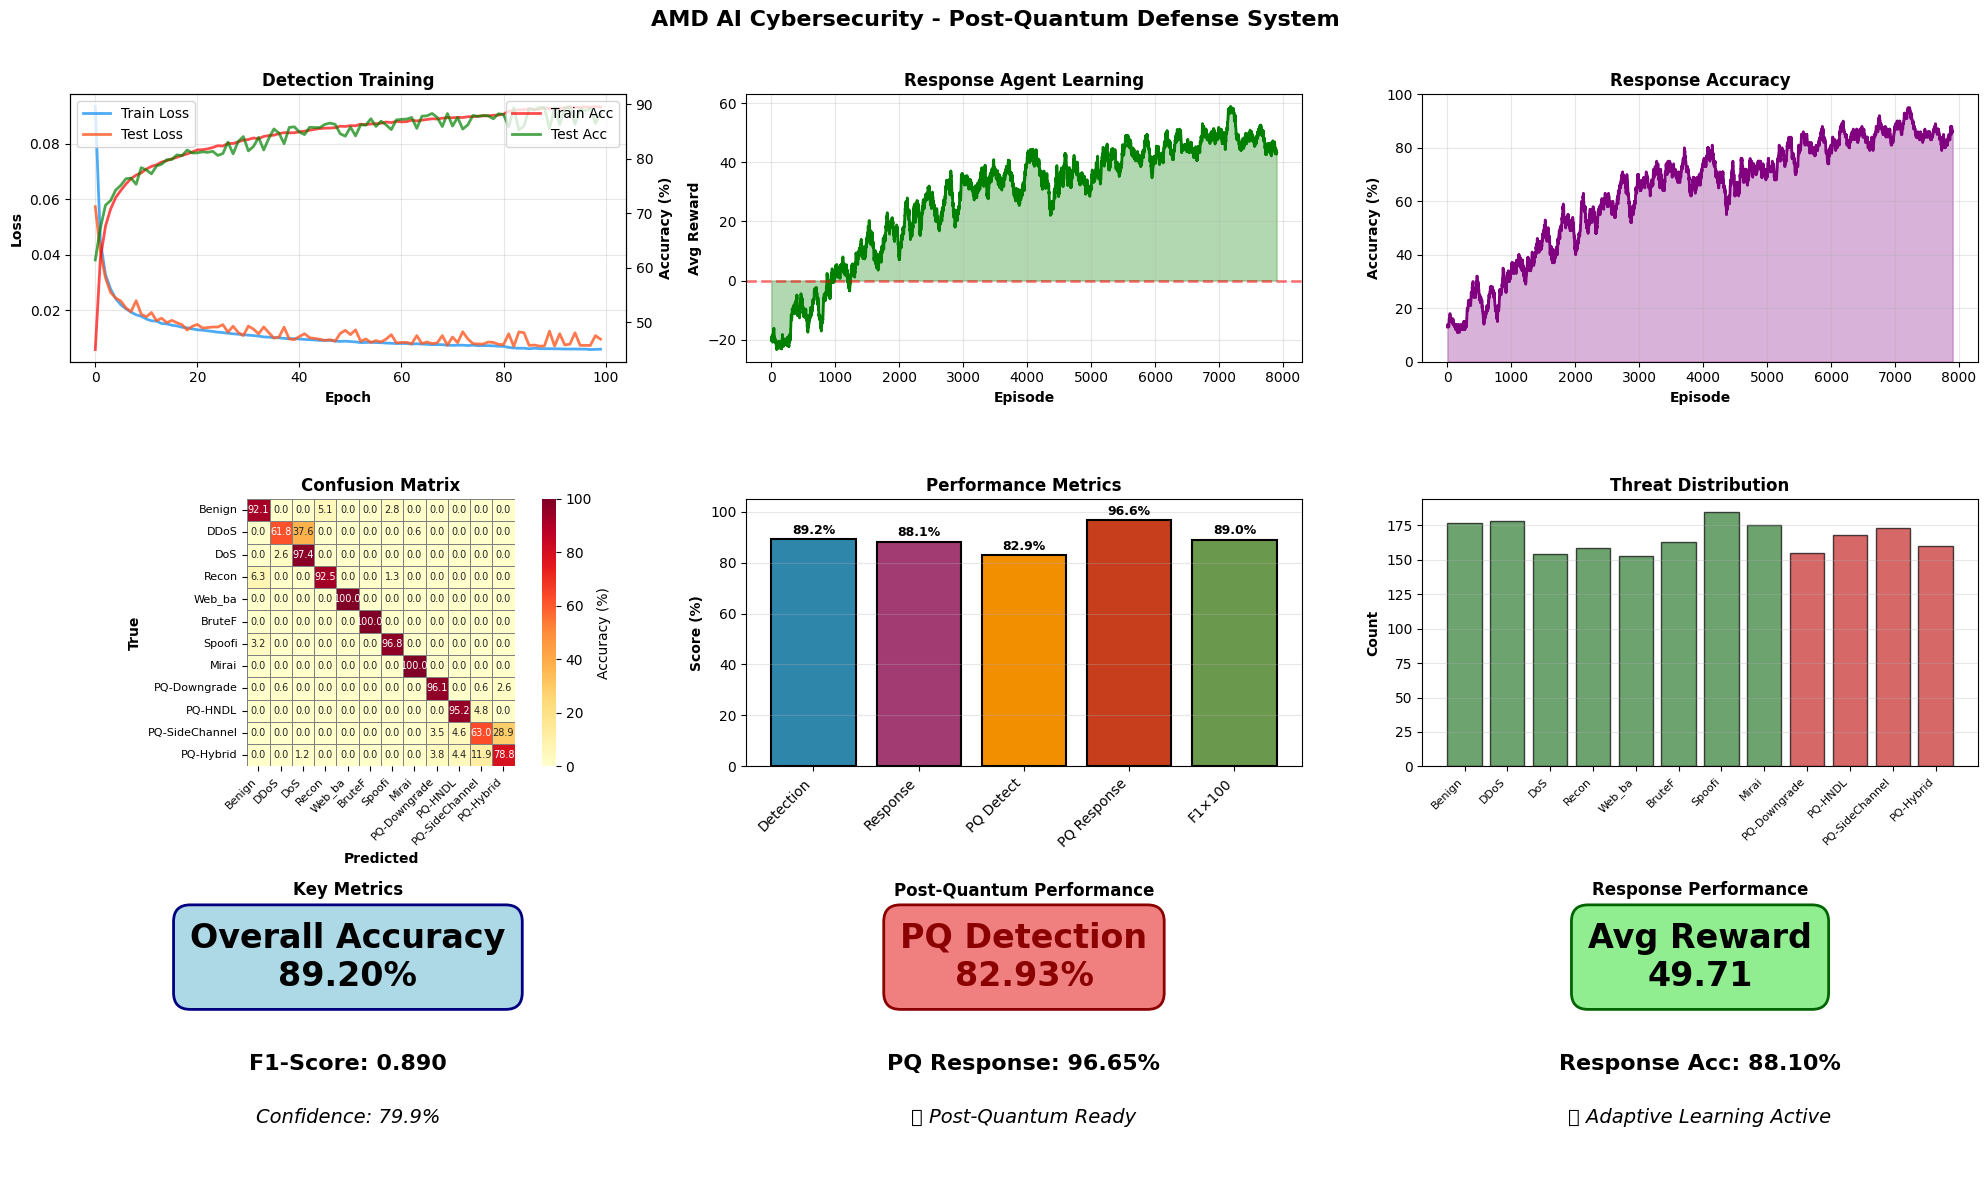

In [15]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("🚀 STARTING AMD AI CYBERSECURITY PIPELINE")
    print("=" * 80)
    
    # Load data
    print("\n[1/6] Loading Dataset...")
    data_loader = ImprovedDataLoader(data_path=INPUT_FOLDER, sample_size=USE_SAMPLE_SIZE)
    X_train, X_test, y_train, y_test, num_features = data_loader.load_dataset()
    threat_names = data_loader.threat_names
    print(f"📊 Data: X_train {X_train.shape}, X_test {X_test.shape}")
    
    # Train detector
    print("\n[2/6] Training Detection Model...")
    detector = EffectiveThreatDetector(input_dim=num_features, num_classes=12).to(device)
    
    total_params = sum(p.numel() for p in detector.parameters())
    trainable_params = sum(p.numel() for p in detector.parameters() if p.requires_grad)
    print(f"🧠 Model: {total_params:,} parameters ({trainable_params:,} trainable)")
    print(f"💾 Size: {total_params * 4 / 1e6:.2f} MB")     
    
    train_losses, test_losses,train_accs, test_accs = train_detector(
        detector, X_train, y_train, X_test, y_test
    )
    
    print("\n" + "=" * 80)
    print("✅ DETECTION TRAINING COMPLETE!")
    print("=" * 80)
    print(f"Final: {test_accs[-1]:.2f}% | Best: {max(test_accs):.2f}%")
    print("=" * 80)
    
    # Train response agent
    print("\n[3/6] Training Response Agent...")
    detector.eval()
    response_agent, episode_rewards, response_accs = train_improved_response_agent(
        detector, threat_names, X_test, y_test, num_episodes=RESPONSE_EPISODES
    )
    
    response_params = sum(p.numel() for p in response_agent.parameters())
    print(f"🤖 Response Agent: {response_params:,} parameters")
    print(f"💾 Size: {response_params * 4 / 1e6:.2f} MB")
    
    # Evaluate
    print("\n[4/6] Evaluating Complete System...")
    results = evaluate_system(detector, response_agent, threat_names, X_test, y_test, num_tests=2000)
    
    # Visualize
    print("\n[5/6] Creating Visualizations...")
    fig = create_visualizations(
        results, train_losses, test_losses,train_accs, test_accs,
        episode_rewards, response_accs, threat_names
    )
    
    # Demo
    print("\n[6/6] Running Real-Time Simulation Demo...")
    sim_results = run_interactive_demo(detector, response_agent, threat_names, X_test, y_test)
    
    # Save
    output_path = Path(OUTPUT_FOLDER)
    output_path.mkdir(parents=True, exist_ok=True)
    
    torch.save(detector.state_dict(), output_path / 'detector.pth')
    torch.save(response_agent.state_dict(), output_path / 'response_agent.pth')
    print(f"\n💾 Models saved to {OUTPUT_FOLDER}/")
    
    fig.savefig(output_path / 'results.png', dpi=300, bbox_inches='tight')
    print(f"📊 Visualization saved")
    
    results_summary = {
        'detection_accuracy': float(results['detection_accuracy']),
        'response_accuracy': float(results['response_accuracy']),
        'pq_detection_accuracy': float(results['pq_detection_accuracy']),
        'pq_response_accuracy': float(results['pq_response_accuracy']),
        'f1_score': float(results['f1_score']),
        'avg_confidence': float(results['avg_confidence']),
        'avg_reward': float(results['avg_reward']),
        'simulation_accuracy': float(sim_results['accuracy']),
        'simulation_final_health': float(sim_results['final_health']),
        'total_parameters': int(total_params + response_params),
        'model_size_mb': float((total_params + response_params) * 4 / 1e6),
        'timestamp': datetime.now().isoformat()
    }
    
    with open(output_path / 'results_summarybaseline.json', 'w') as f:
        json.dump(results_summary, f, indent=2)
    print(f"📄 Results saved")
    
    # Final summary
    print("\n" + "=" * 80)
    print("🎉 PIPELINE COMPLETE!")
    print("=" * 80)
    print("\n📈 FINAL RESULTS:")
    print(f"    Detection: {results['detection_accuracy']:.2f}%")
    print(f"    PQ Detection: {results['pq_detection_accuracy']:.2f}%")
    print(f"    Response: {results['response_accuracy']:.2f}%")
    print(f"    PQ Response: {results['pq_response_accuracy']:.2f}%")
    print(f"    F1-Score: {results['f1_score']:.3f}")
    print(f"    Avg Reward: {results['avg_reward']:.2f}")
    print(f"    Simulation Accuracy: {sim_results['accuracy']:.1f}%")
    print("\n💾 MODEL SIZE:")
    print(f"   Total: {total_params + response_params:,} parameters")
    print(f"   Size: {(total_params + response_params) * 4 / 1e6:.2f} MB")
    print("=" * 80)
    
    plt.show()


In [16]:
import pickle
from pathlib import Path

with open("/home/user2/archive(9)/scaler.pkl", "wb") as f:
    pickle.dump(data_loader.scaler, f)


In [17]:
import pickle

with open("/home/user2/archive(9)/scaler.pkl", "rb") as f:
    obj = pickle.load(f)

print(type(obj))   # see what kind of object it is
print(obj)         # print its contents


<class 'sklearn.preprocessing._data.StandardScaler'>
StandardScaler()


In [18]:
import pickle

with open("/home/user2/archive(9)/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print(f"Type            : {type(scaler)}")
print(f"Feature count   : {scaler.n_features_in_}")
print(f"Mean            : {scaler.mean_}")
print(f"Std / Scale     : {scaler.scale_}")
print(f"Variance        : {scaler.var_}")


Type            : <class 'sklearn.preprocessing._data.StandardScaler'>
Feature count   : 39
Mean            : [1.37511799e+01 9.10231000e+00 6.65799189e+01 2.84371203e+04
 8.61428943e-02 2.08029022e-01 9.21601258e-02 9.36227754e-02
 1.29620512e-01 3.07000000e-05 1.52000000e-05 9.84194000e+00
 2.05499700e+01 8.52515000e+00 9.09236000e+00 5.02388000e-02
 5.86704892e-02 2.69953310e-03 7.90000000e-06 9.20000000e-06
 2.24200000e-04 1.27000000e-05 5.75872316e-01 2.15917502e-01
 1.69500000e-04 2.94866287e-03 1.63217936e-01 2.14000000e-05
 9.97051337e-01 9.97051337e-01 1.08968443e+04 7.98757300e+01
 2.20759700e+02 1.30460849e+02 4.03199351e+01 1.30460849e+02
 7.70674172e-04 9.54552800e+01 3.47421165e+04]
Std / Scale     : [8.72842378e+00 9.13903292e+00 1.48120318e+01 2.80636786e+04
 2.78135300e-01 4.00639571e-01 2.82212148e-01 2.76655097e-01
 3.16275288e-01 1.84175392e-03 1.31672661e-03 2.80006753e+01
 4.00217351e+01 2.78016112e+01 2.81114103e+01 2.13506325e-01
 2.19145825e-01 2.26101410e-02 2